In [1]:
from src.DataFolder import DataFolder
from src.NeuralSignal import NeuralSignal
from src.runtime_logger import logger_setup

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neurodsp.spectral import compute_spectrum

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Setup

### Load the config file

In [2]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
lowpass_length      = args.pop("lowpass_length")
bandpass_length     = args.pop("bandpass_length")
threshold_bycycle   = args.pop("threshold_bycycle")
threshold_episode   = args.pop("threshold_episode")

# Start logger
logger = logger_setup()

### Load the dataset

In [3]:
remFolder = DataFolder(data_path)

# Analysis

## Dataset

In [5]:
spectrum_phasic = []
spectrum_tonic = []

# Compute frequency statistics
n_bins = 45
freq = np.arange(2, 46)

for sample in remFolder:
    lfpREMs = sample["data"]
    
    for lfpREM in lfpREMs:
        
        if(len(lfpREM) < 2500): 
            break    #Skip when the duration is less than a second
        
        theta = NeuralSignal(lfpREM, fs)
        theta.filter('lowpass', f_range=f_lowpass, n_seconds=lowpass_length)
        theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)

        theta_tonic = np.zeros((len(theta.tonic), n_bins))
        theta_phasic = np.zeros((len(theta.phasic), n_bins))

        for i, tonic in enumerate(theta.get_tonic(filter_type="raw")):
            f, spectrum = compute_spectrum(tonic, theta.fs, method='welch', avg_type='mean')
            theta_tonic[i, :] = spectrum[1:46]
            logger.debug("signal shape: {0}".format(tonic.shape))

        for i, phasic in enumerate(theta.get_phasic(filter_type="raw")):
            f, spectrum = compute_spectrum(phasic, theta.fs, method='welch', avg_type='mean')
            theta_phasic[i, :] = spectrum[1:46]
            logger.debug("signal shape: {0}".format(phasic.shape))
            
        spectrum_tonic.append(theta_tonic)
        spectrum_phasic.append(theta_phasic)

spectrum_phasic = np.vstack(spectrum_phasic)
spectrum_tonic = np.vstack(spectrum_tonic)

phasic_spectrum_mean = np.mean(spectrum_phasic, axis=0)
tonic_spectrum_mean = np.mean(spectrum_tonic, axis=0)

phasic_spectrum_std = np.std(spectrum_phasic, axis=0)
tonic_spectrum_std = np.std(spectrum_tonic, axis=0)


/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 2500 is greater than input length  = 2136, using nperseg = 2136
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 2500 is greater than input length  = 2127, using nperseg = 2127
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 2500 is greater than input length  = 2426, using nperseg = 2426
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 2500 is greater than input length  = 2410, using nperseg = 2410
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/

KeyboardInterrupt: 

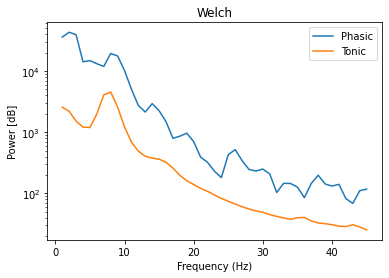

In [15]:
freq = np.arange(1, 46)
plt.plot(freq, phasic_spectrum_mean)
plt.plot(freq, tonic_spectrum_mean)

#plt.fill_between(freq, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power [dB]')

plt.yscale('log')
#plt.xscale('log')

plt.title('Welch')
plt.legend(['Phasic', 'Tonic'])

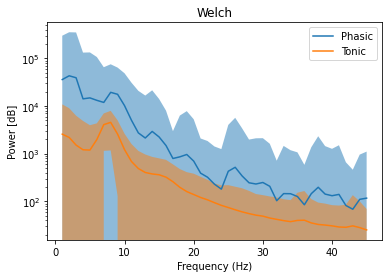

In [27]:
freq = np.arange(1, 46)
plt.plot(freq, phasic_spectrum_mean)
plt.plot(freq, tonic_spectrum_mean)

plt.fill_between(freq, phasic_spectrum_mean + phasic_spectrum_std,
                 phasic_spectrum_mean - phasic_spectrum_std, 
                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')

plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
                 tonic_spectrum_mean + tonic_spectrum_std, 
                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power [dB]')

plt.yscale('log')
#plt.xscale('log')

plt.title('Welch')
plt.legend(['Phasic', 'Tonic'])

In [35]:
spectrum_phasic[0]

array([6.85714891e+01, 6.57052676e+00, 2.71148403e+01, 1.29296182e+02,
       2.62958220e+02, 2.03053082e+02, 3.99479374e+03, 1.03064519e+04,
       1.61646067e+03, 1.68877989e+02, 4.61264232e+01, 8.57523801e+00,
       5.82929999e+01, 8.18024486e+01, 3.49236465e+02, 4.71663254e+02,
       5.08096363e+01, 2.47111594e+00, 3.77351038e+00, 4.29930665e+01,
       5.90768992e+01, 3.84088407e+01, 2.41213145e+01, 1.66057057e+01,
       1.19826853e+01, 4.66546022e+01, 1.64461940e+01, 3.20350828e+01,
       1.04338600e+01, 8.09657963e-02, 1.16503829e+01, 1.87652845e+01,
       2.86631343e-01, 1.70248864e+01, 1.62554296e+01, 1.84939051e+01,
       3.63838027e+01, 1.19669659e+01, 1.20220817e+01, 1.05713866e+01,
       1.93427216e+01, 1.07498479e+01, 1.64081752e+01, 1.14915551e+01,
       6.94875747e+00])

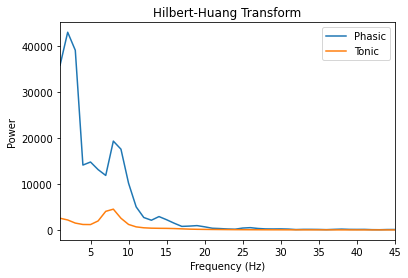

In [17]:
plt.plot(freq, phasic_spectrum_mean)
plt.plot(freq, tonic_spectrum_mean)

#plt.fill_between(freq, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlim(1, 45)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

plt.yscale('linear')

plt.title('Hilbert-Huang Transform')
plt.legend(['Phasic', 'Tonic'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7f90bfc1c370>,
 'caps': [<matplotlib.lines.Line2D at 0x7f90bfc1c910>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f90bfc1c190>,
 'medians': [<matplotlib.lines.Line2D at 0x7f90bfc1ceb0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f90bfc1d180>,
 'means': []}

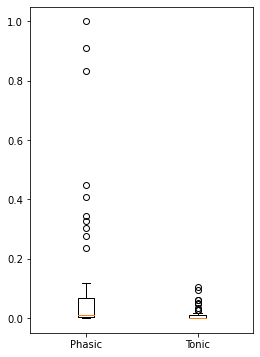

In [20]:
plt.figure(figsize=(4,6))
plt.boxplot([phasic_spectrum_mean/phasic_spectrum_mean.max(),
             tonic_spectrum_mean/phasic_spectrum_mean.max()],
            labels=["Phasic", "Tonic"])

In [21]:
df_phasic = pd.DataFrame(phasic_spectrum_mean)
df_tonic  = pd.DataFrame(tonic_spectrum_mean)
df_phasic

,0
0,35919.563432
1,43095.081896
2,39170.849983
3,14155.794076
4,14817.391825
5,13163.081071
6,11897.749578
7,19374.629561
8,17618.455623
9,10203.083884
